DELSON FERNANDES 60302101

In [1]:
# ============================
# BLOCK 1 — IMPORT LIBRARIES
# ============================

import pandas as pd
import numpy as np

In [2]:
# ============================
# BLOCK 2 — LOAD DATA
# ============================

calendar = pd.read_csv("calendar.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")
stores = pd.read_csv("stores.csv")

In [3]:
# ============================
# BLOCK 3 — BASIC INSPECTION
# ============================

datasets = {
    "calendar": calendar,
    "customers": customers,
    "products": products,
    "sales": sales,
    "stores": stores
}

for name, df_ in datasets.items():
    print(f"\n{'='*50}")
    print(f"{name.upper()} DATASET")
    print(f"{'='*50}")
    print("Shape:", df_.shape)
    print("\nColumns:")
    print(df_.columns.tolist())
    print("\nData types:")
    print(df_.dtypes)
    print("\nFirst 5 rows:")
    print(df_.head())


CALENDAR DATASET
Shape: (731, 6)

Columns:
['date', 'year', 'month', 'day', 'week', 'day_of_week']

Data types:
date           object
year            int64
month           int64
day             int64
week            int64
day_of_week     int64
dtype: object

First 5 rows:
         date  year  month  day  week  day_of_week
0  2023-01-01  2023      1    1    52            6
1  2023-01-02  2023      1    2     1            0
2  2023-01-03  2023      1    3     1            1
3  2023-01-04  2023      1    4     1            2
4  2023-01-05  2023      1    5     1            3

CUSTOMERS DATASET
Shape: (50000, 5)

Columns:
['customer_id', 'age', 'gender', 'loyalty_member', 'join_date']

Data types:
customer_id       object
age                int64
gender            object
loyalty_member     int64
join_date         object
dtype: object

First 5 rows:
  customer_id  age  gender  loyalty_member   join_date
0     C000001   40    Male               1  2025-05-21
1     C000002   47    Male      

In [4]:
# In this step, all datasets were successfully loaded and inspected to understand their structure,
# including the number of records, column names, data types, and sample values. This initial
# exploration confirms that the dataset meets the project requirements (multiple tables and sufficient features)
# and helps identify key relationships between tables (e.g., product_id, customer_id, store_id, and date).
# It also highlights important preprocessing needs such as handling date formats and categorical variables,
# which will be addressed in the next steps.

In [5]:
# ============================
# BLOCK 4 — CLEAN COLUMN NAMES
# ============================

for df_ in [calendar, customers, products, sales, stores]:
    df_.columns = df_.columns.str.strip().str.lower()

print("Calendar columns:", calendar.columns.tolist())
print("Customers columns:", customers.columns.tolist())
print("Products columns:", products.columns.tolist())
print("Sales columns:", sales.columns.tolist())
print("Stores columns:", stores.columns.tolist())

Calendar columns: ['date', 'year', 'month', 'day', 'week', 'day_of_week']
Customers columns: ['customer_id', 'age', 'gender', 'loyalty_member', 'join_date']
Products columns: ['product_id', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g']
Sales columns: ['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit']
Stores columns: ['store_id', 'store_name', 'city', 'country', 'store_type']


In [6]:
# In this step, column names across all datasets were standardized by removing extra spaces
# and converting them to lowercase. This ensures consistency when merging datasets and
# avoids errors caused by mismatched column names during data processing.

In [7]:
# ============================
# BLOCK 5 — CLEAN KEY COLUMNS
# ============================

key_columns = {
    "sales": ["order_id", "product_id", "store_id", "customer_id"],
    "products": ["product_id"],
    "customers": ["customer_id"],
    "stores": ["store_id"]
}

# Convert ID columns to string and strip spaces
for col in key_columns["sales"]:
    sales[col] = sales[col].astype(str).str.strip()

for col in key_columns["products"]:
    products[col] = products[col].astype(str).str.strip()

for col in key_columns["customers"]:
    customers[col] = customers[col].astype(str).str.strip()

for col in key_columns["stores"]:
    stores[col] = stores[col].astype(str).str.strip()

# Dates
sales["order_date"] = pd.to_datetime(sales["order_date"], errors="coerce")
calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")

In [8]:
# In this step, key identifier columns (such as product_id, customer_id, and store_id)
# were cleaned by converting them to string format and removing any extra spaces.
# This ensures consistency across datasets and prevents mismatches during merging.
# Additionally, relevant date columns (order_date and calendar date) were converted
# to datetime format to enable time-based analysis and accurate joins.

In [9]:
# ============================
# BLOCK 6 — CHECK DUPLICATE KEYS
# ============================

print("Duplicate product_id in products:", products["product_id"].duplicated().sum())
print("Duplicate customer_id in customers:", customers["customer_id"].duplicated().sum())
print("Duplicate store_id in stores:", stores["store_id"].duplicated().sum())
print("Duplicate date in calendar:", calendar["date"].duplicated().sum())

Duplicate product_id in products: 0
Duplicate customer_id in customers: 0
Duplicate store_id in stores: 0
Duplicate date in calendar: 0


In [10]:
# In this step, duplicate values in key columns were checked to ensure data integrity
# before merging the datasets. The results show that there are no duplicate entries
# in the primary key fields (product_id, customer_id, store_id, and date),
# confirming that each dataset can be reliably joined without creating duplication issues.

In [11]:
# ============================
# BLOCK 7 — CHECK NON-MATCHING KEYS
# ============================

# Product IDs in sales not found in products
unmatched_products = sorted(set(sales["product_id"]) - set(products["product_id"]))

# Customer IDs in sales not found in customers
unmatched_customers = sorted(set(sales["customer_id"]) - set(customers["customer_id"]))

# Store IDs in sales not found in stores
unmatched_stores = sorted(set(sales["store_id"]) - set(stores["store_id"]))

# Dates in sales not found in calendar
unmatched_dates = sorted(set(sales["order_date"]) - set(calendar["date"]))

print("Unmatched product IDs:", len(unmatched_products))
print("Unmatched customer IDs:", len(unmatched_customers))
print("Unmatched store IDs:", len(unmatched_stores))
print("Unmatched dates:", len(unmatched_dates))

Unmatched product IDs: 2
Unmatched customer IDs: 0
Unmatched store IDs: 0
Unmatched dates: 0


### Checking Non-Matching Keys

In this step, I verified whether all foreign keys in the sales dataset correctly match
their corresponding reference tables (products, customers, stores, and calendar).

The results show:
- 2 product IDs in the sales dataset do not exist in the products table
- No mismatches were found for customers, stores, or dates

This indicates that the data is largely consistent, but a small number of product records
are missing corresponding product information. These unmatched entries will be handled
in later preprocessing steps to ensure they do not affect model performance or analysis.

In [12]:
# ============================
# BLOCK 8 — SHOW  NON-MATCHES
# ============================

print("Sample unmatched product IDs:", unmatched_products[:10])
print("Sample unmatched customer IDs:", unmatched_customers[:10])
print("Sample unmatched store IDs:", unmatched_stores[:10])
print("Sample unmatched dates:", unmatched_dates[:10])

Sample unmatched product IDs: ['P0000', 'P0201']
Sample unmatched customer IDs: []
Sample unmatched store IDs: []
Sample unmatched dates: []


### Inspecting Non-Matching Keys

In this step, I examined examples of unmatched keys to better understand the inconsistencies identified earlier.

The results show that the unmatched product IDs are:
- P0000
- P0201

No unmatched customer IDs, store IDs, or dates were found.

This confirms that the mismatch issue is limited to a very small number of product records, which can be handled during the merging or preprocessing stage without significantly affecting the overall analysis.

In [13]:
# ============================
# BLOCK 9 — SHOW ROWS CAUSING MISMATCH
# ============================

if len(unmatched_products) > 0:
    print("\nRows in sales with unmatched product_id:")
    display(sales[sales["product_id"].isin(unmatched_products)].head())

if len(unmatched_customers) > 0:
    print("\nRows in sales with unmatched customer_id:")
    display(sales[sales["customer_id"].isin(unmatched_customers)].head())

if len(unmatched_stores) > 0:
    print("\nRows in sales with unmatched store_id:")
    display(sales[sales["store_id"].isin(unmatched_stores)].head())

if len(unmatched_dates) > 0:
    print("\nRows in sales with unmatched order_date:")
    display(sales[sales["order_date"].isin(unmatched_dates)].head())


Rows in sales with unmatched product_id:


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
193,0RD00000194,2023-11-06,P0000,S031,C020512,3,12.51,0.20,30.02,20.70,9.32
390,0RD00000391,2023-02-06,P0201,S061,C005192,3,4.57,0.00,13.71,8.41,5.30
433,0RD00000434,2023-06-15,P0000,S018,C006897,2,9.64,0.15,16.39,10.41,5.98
714,0RD00000715,2024-12-21,P0201,S042,C002777,1,8.40,0.00,8.40,5.60,2.80
748,0RD00000749,2023-06-16,P0201,S045,C013828,3,4.33,0.15,11.04,7.22,3.82


### Inspecting Rows with Unmatched Product IDs

In this step, I displayed the sales records associated with the unmatched product IDs identified earlier.

The output confirms that the mismatch is caused by transactions containing product IDs `P0000` and `P0201`, which are present in the sales dataset but missing from the products reference table.

This step is useful because it verifies that the issue is limited to specific records rather than a broader data quality problem. These rows will need to be handled appropriately during preprocessing so that missing product information does not affect the merged dataset or later analysis.

In [14]:
# ============================
# BLOCK 10 — MERGE ALL TABLES
# ============================

df = sales.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(stores, on="store_id", how="left")
df = df.merge(calendar, left_on="order_date", right_on="date", how="left")

df = df.copy()

# ============================
# CHECK MISSING BEFORE CLEANING
# ============================

print("Missing BEFORE cleaning:")
print(df.isnull().sum())

Missing BEFORE cleaning:
order_id             0
order_date           0
product_id           0
store_id             0
customer_id          0
quantity             0
unit_price           0
discount             0
revenue              0
cost                 0
profit               0
age                  0
gender               0
loyalty_member       0
join_date            0
product_name      9764
brand             9764
category          9764
cocoa_percent     9764
weight_g          9764
store_name           0
city                 0
country              0
store_type           0
date                 0
year                 0
month                0
day                  0
week                 0
day_of_week          0
dtype: int64


### Merging the Datasets

In this step, all tables were merged into a single analytical dataset using left joins, with the sales table used as the main fact table. Customer, product, store, and calendar information were added based on their corresponding key columns.

After merging, a missing value check was performed to evaluate the quality of the combined dataset. The results show that missing values appear only in product-related columns such as `product_name`, `brand`, `category`, `cocoa_percent`, and `weight_g`.

This is consistent with the earlier validation step, where two product IDs in the sales table did not have matching records in the products table. Therefore, the missing values are expected and are limited to product attributes only, while the rest of the merged dataset remains complete.

In [15]:
# ============================
# BLOCK 11 — HANDLE MISSING VALUES
# ============================

# Fill product-related missing categorical values
df['product_name'] = df['product_name'].fillna('Unknown')
df['brand'] = df['brand'].fillna('Unknown')
df['category'] = df['category'].fillna('Unknown')

# Fill product-related missing numerical values using median
df['cocoa_percent'] = df['cocoa_percent'].fillna(df['cocoa_percent'].median())
df['weight_g'] = df['weight_g'].fillna(df['weight_g'].median())

# Final check
print("Remaining missing values:")
print(df.isnull().sum())

print("Merged dataset shape:", df.shape)
display(df.head())

Remaining missing values:
order_id          0
order_date        0
product_id        0
store_id          0
customer_id       0
quantity          0
unit_price        0
discount          0
revenue           0
cost              0
profit            0
age               0
gender            0
loyalty_member    0
join_date         0
product_name      0
brand             0
category          0
cocoa_percent     0
weight_g          0
store_name        0
city              0
country           0
store_type        0
date              0
year              0
month             0
day               0
week              0
day_of_week       0
dtype: int64
Merged dataset shape: (1000000, 30)


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,store_name,city,country,store_type,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,Chocolate Store 93,Sydney,UK,Airport,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,Chocolate Store 65,New York,Australia,Retail,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,Chocolate Store 78,London,UK,Airport,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,Chocolate Store 88,Toronto,USA,Retail,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,Chocolate Store 54,London,Canada,Online,2024-09-24,2024,9,24,39,1


### Handling Missing Values

In this step, missing values in the merged dataset were handled to ensure data quality before analysis and modeling.

Since the missing values were limited to product-related attributes caused by unmatched product IDs, categorical fields such as `product_name`, `brand`, and `category` were filled with `"Unknown"`. Numerical fields (`cocoa_percent` and `weight_g`) were filled using the median to preserve the overall distribution of the data.

After applying these transformations, a final check confirmed that there are no remaining missing values in the dataset. The dataset remains complete with 1,000,000 rows and 30 columns, ensuring it is ready for exploratory analysis and model development.

In [16]:
# ============================
# BLOCK 12 — CHECK PRODUCT-RELATED MISSING VALUES
# ============================

product_missing_rows = df[df["product_name"].isnull()]

print("Rows with missing product_name:", product_missing_rows.shape[0])

if product_missing_rows.shape[0] > 0:
    display(product_missing_rows[["product_id", "product_name", "brand", "category"]].head(20))
else:
    print("No missing product information after merge.")

Rows with missing product_name: 0
No missing product information after merge.


In [17]:
# ============================
# BLOCK 14 — DATA QUALITY SUMMARY
# ============================

print("Sales rows:", len(sales))
print("Unique product IDs in sales:", sales["product_id"].nunique())
print("Unique product IDs in products:", products["product_id"].nunique())
print("Unique customer IDs in sales:", sales["customer_id"].nunique())
print("Unique customer IDs in customers:", customers["customer_id"].nunique())
print("Unique store IDs in sales:", sales["store_id"].nunique())
print("Unique store IDs in stores:", stores["store_id"].nunique())
print("Date range in sales:", sales["order_date"].min(), "to", sales["order_date"].max())
print("Date range in calendar:", calendar["date"].min(), "to", calendar["date"].max())

Sales rows: 1000000
Unique product IDs in sales: 202
Unique product IDs in products: 200
Unique customer IDs in sales: 50000
Unique customer IDs in customers: 50000
Unique store IDs in sales: 100
Unique store IDs in stores: 100
Date range in sales: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Date range in calendar: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


In [18]:
print(sales.shape)
print(len(sales))
sales.info()

(1000000, 11)
1000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 83.9+ MB


### Data Quality Summary

In this step, a summary of the dataset was generated to validate data consistency and completeness.

The results show that:
- The sales dataset contains 1,000,000 records, confirming a large dataset suitable for analysis
- The number of unique customer IDs and store IDs in the sales dataset matches their respective reference tables, indicating consistent relationships
- There are 202 unique product IDs in the sales dataset compared to 200 in the products table, confirming the presence of a small number of unmatched product IDs identified earlier
- The date ranges in both the sales and calendar datasets align perfectly (2023 to 2024), ensuring accurate time-based merging and analysis

Overall, the dataset is consistent, complete, and well-structured, with only minor discrepancies that have already been addressed during preprocessing.

In [19]:
df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

,revenue
product_name,
Dark Chocolate 50%,1775041.34
Truffle Chocolate 80%,1643258.83
Milk Chocolate 70%,1384758.27
Praline Chocolate 50%,1382597.04
Dark Chocolate 60%,1272649.97
White Chocolate 50%,1265949.75
White Chocolate 90%,1137968.57
White Chocolate 80%,1133285.39
Truffle Chocolate 90%,1132883.80


The analysis identifies the top 10 chocolate products based on total revenue. Dark Chocolate 50% generates the highest revenue, followed closely by Truffle Chocolate 80% and Milk Chocolate 70%. This suggests that customers prefer premium or higher cocoa content products, which can guide pricing strategies and product promotions. These insights can help the business prioritize high-performing products for marketing, inventory planning, and sales strategy.

In [20]:
df.groupby('store_name')['revenue'].sum().sort_values(ascending=False)

,revenue
store_name,
Chocolate Store 74,261393.77
Chocolate Store 33,260672.37
Chocolate Store 50,259526.62
Chocolate Store 85,259512.15
Chocolate Store 98,259055.13
...,...
Chocolate Store 77,250220.40
Chocolate Store 2,249737.67
Chocolate Store 48,249272.38


The store-level revenue analysis shows that Chocolate Store 74 generates the highest revenue, followed closely by Stores 33 and 50. Overall, the revenue distribution across stores appears relatively consistent, with only moderate differences between the top and lower-performing stores. This suggests that sales performance is fairly balanced across locations, with no single store dominating significantly. These insights can help the business identify top-performing stores while also exploring opportunities to improve performance in lower-ranked locations.This indicates consistent operational performance across locations, suggesting that external factors such as location or store type may have limited impact on revenue variation.

In [21]:
# ============================
# BLOCK 15 — FINAL CLEANING + FEATURE ENGINEERING
# ============================

# Making a safe copy
df = df.copy()

# ----------------------------
# 1. Date handling
# ----------------------------
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")


#e create useful date features directly from order_date.
if "year" not in df.columns:
    df["year"] = df["order_date"].dt.year

if "month" not in df.columns:
    df["month"] = df["order_date"].dt.month

if "day" not in df.columns:
    df["day"] = df["order_date"].dt.day

if "quarter" not in df.columns:
    df["quarter"] = df["order_date"].dt.quarter

df["day_name"] = df["order_date"].dt.day_name()
df["is_weekend"] = df["day_name"].isin(["Saturday", "Sunday"]).astype(int)

# ----------------------------
# 2. Customer age cleanup
# ----------------------------
if "age" in df.columns:
    df["age"] = pd.to_numeric(df["age"], errors="coerce")

    df["age_group"] = pd.cut(
        df["age"],
        bins=[0, 18, 25, 35, 45, 60, 100],
        labels=["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]
    )

# ----------------------------
# 3. Create important business metrics
# ----------------------------
if "revenue" in df.columns and "quantity" in df.columns:
    df["avg_selling_price"] = df["revenue"] / df["quantity"].replace(0, np.nan)

if "profit" in df.columns and "revenue" in df.columns:
    df["profit_margin"] = df["profit"] / df["revenue"].replace(0, np.nan)

if "discount" in df.columns:
    df["discount"] = pd.to_numeric(df["discount"], errors="coerce")

    df["discount_flag"] = (df["discount"] > 0).astype(int)

    df["discount_band"] = pd.cut(
        df["discount"],
        bins=[-0.01, 0, 5, 10, 20, 100],
        labels=["No Discount", "Low", "Medium", "High", "Very High"]
    )

# ----------------------------
# 4. Flags for missing / unmatched dimension info
# ----------------------------
df["unknown_product_flag"] = (df["product_name"] == "Unknown").astype(int)
df["unknown_store_flag"] = (df["store_name"] == "Unknown").astype(int)

if "city" in df.columns:
    df["unknown_customer_city_flag"] = (df["city"] == "Unknown").astype(int)

# ----------------------------
# 5. Final duplicate check
# ----------------------------
print("Duplicate rows in merged df:", df.duplicated().sum())

# ----------------------------
# 6. Final summary
# ----------------------------
print("\nFinal dataframe shape:", df.shape)

print("\nMissing values after feature engineering:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nNumeric summary:")
display(df.describe())

print("\nSample rows:")
display(df.head())

Duplicate rows in merged df: 0

Final dataframe shape: (1000000, 41)

Missing values after feature engineering:
order_id          0
order_date        0
product_id        0
store_id          0
customer_id       0
quantity          0
unit_price        0
discount          0
revenue           0
cost              0
profit            0
age               0
gender            0
loyalty_member    0
join_date         0
product_name      0
brand             0
category          0
cocoa_percent     0
weight_g          0
dtype: int64

Numeric summary:


,order_date,quantity,unit_price,discount,revenue,cost,profit,age,loyalty_member,cocoa_percent,...,week,day_of_week,quarter,is_weekend,avg_selling_price,profit_margin,discount_flag,unknown_product_flag,unknown_store_flag,unknown_customer_city_flag
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.0
mean,2023-12-31 19:03:34.991998720,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565,44.044222,0.501898,69.15645,...,26.444866,2.999049,2.506426,0.286440,8.496254,0.399980,0.374872,0.009764,0.0,0.0
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,18.000000,0.000000,50.00000,...,1.000000,0.000000,1.000000,0.000000,2.400000,0.298701,0.000000,0.000000,0.0,0.0
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,31.000000,0.000000,50.00000,...,13.000000,1.000000,2.000000,0.000000,5.624000,0.350061,0.000000,0.000000,0.0,0.0
50%,2024-01-01 00:00:00,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000,44.000000,1.000000,70.00000,...,26.000000,3.000000,3.000000,0.000000,8.440000,0.399936,0.000000,0.000000,0.0,0.0
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000,57.000000,1.000000,80.00000,...,39.000000,5.000000,4.000000,1.000000,11.240000,0.449889,1.000000,0.000000,0.0,0.0
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,70.000000,1.000000,90.00000,...,52.000000,6.000000,4.000000,1.000000,15.000000,0.501767,1.000000,1.000000,0.0,0.0
std,NaN,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760,15.330664,0.499997,14.52594,...,15.069053,2.003559,1.117330,0.452098,3.351335,0.057691,0.484090,0.098329,0.0,0.0



Sample rows:


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,day_name,is_weekend,age_group,avg_selling_price,profit_margin,discount_flag,discount_band,unknown_product_flag,unknown_store_flag,unknown_customer_city_flag
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,Saturday,1,36-45,12.266,0.302625,1,Low,0,0,0
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,Sunday,1,60+,12.010,0.470996,0,No Discount,0,0,0
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,Sunday,1,26-35,10.020,0.486527,0,No Discount,0,0,0
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,Sunday,1,36-45,13.195,0.380447,1,Low,0,0,0
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,Tuesday,0,46-60,12.340,0.356564,0,No Discount,0,0,0


In [22]:
# ============================
# BLOCK 16 — CORE BUSINESS EDA SUMMARY
# ============================

print("Total Revenue:", round(df["revenue"].sum(), 2))
print("Total Profit:", round(df["profit"].sum(), 2))
print("Total Quantity Sold:", int(df["quantity"].sum()))
print("Average Order Revenue:", round(df["revenue"].mean(), 2))
print("Average Order Profit:", round(df["profit"].mean(), 2))
print("Average Profit Margin:", round(df["profit_margin"].mean(), 4))

print("\nDate Range:")
print("Start:", df["order_date"].min())
print("End:", df["order_date"].max())

print("\nUnique Counts:")
print("Products:", df["product_id"].nunique())
print("Stores:", df["store_id"].nunique())
print("Customers:", df["customer_id"].nunique())
print("Categories:", df["category"].nunique())
print("Brands:", df["brand"].nunique())

print("\nDiscount Usage:")
print(df["discount_band"].value_counts(dropna=False))

print("\nLoyalty Member Distribution:")
print(df["loyalty_member"].value_counts(dropna=False))

print("\nGender Distribution:")
print(df["gender"].value_counts(dropna=False))

print("\nAge Group Distribution:")
print(df["age_group"].value_counts(dropna=False))

print("\nTop 10 Categories by Revenue:")
print(df.groupby("category")["revenue"].sum().sort_values(ascending=False).head(10))

print("\nTop 10 Brands by Revenue:")
print(df.groupby("brand")["revenue"].sum().sort_values(ascending=False).head(10))

print("\nTop 10 Stores by Revenue:")
print(df.groupby("store_name")["revenue"].sum().sort_values(ascending=False).head(10))

print("\nBottom 10 Stores by Revenue:")
print(df.groupby("store_name")["revenue"].sum().sort_values(ascending=True).head(10))

Total Revenue: 25486128.86
Total Profit: 10194564.63
Total Quantity Sold: 2999589
Average Order Revenue: 25.49
Average Order Profit: 10.19
Average Profit Margin: 0.4

Date Range:
Start: 2023-01-01 00:00:00
End: 2024-12-31 00:00:00

Unique Counts:
Products: 202
Stores: 100
Customers: 50000
Categories: 6
Brands: 7

Discount Usage:
discount_band
No Discount    625128
Low            374872
Medium              0
High                0
Very High           0
Name: count, dtype: int64

Loyalty Member Distribution:
loyalty_member
1    501898
0    498102
Name: count, dtype: int64

Gender Distribution:
gender
Male      504311
Female    495689
Name: count, dtype: int64

Age Group Distribution:
age_group
46-60    282487
60+      191005
36-45    188389
26-35    185700
19-25    133342
0-18      19077
Name: count, dtype: int64

Top 10 Categories by Revenue:
category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Unknown     247480.64
Name: 

# ============================
# INTERPRETATION OF KEY VISUALS
# ============================

From the visual analysis, several important business insights can be observed.

The monthly revenue trend shows relatively stable sales patterns across both 2023 and 2024, with no extreme spikes or drops. This suggests that chocolate sales are consistent throughout the year, with only mild seasonal variation. This stability is useful for forecasting and inventory planning.

When analyzing revenue by category, products such as Praline, White, and Dark chocolate clearly generate the highest revenue. These categories appear to be the main drivers of business performance, indicating that the company should prioritize them in marketing and stock decisions.

Revenue by gender is fairly balanced, which suggests that chocolate products appeal equally to both male and female customers. Similarly, the age group analysis shows that most revenue comes from customers between 26 and 60 years old, indicating that this is the core target segment for the business.

The discount analysis reveals that most transactions occur without discounts, and even when discounts are applied, they are relatively small. This indicates that the company does not rely heavily on promotions to drive sales, and customers are willing to purchase at regular prices.

Finally, comparing weekend and weekday performance shows only a small difference in average revenue, suggesting that purchasing behavior is consistent throughout the week rather than concentrated on weekends.

Overall, these insights suggest that sales performance is driven more by product category and customer demographics rather than timing or heavy promotional strategies.

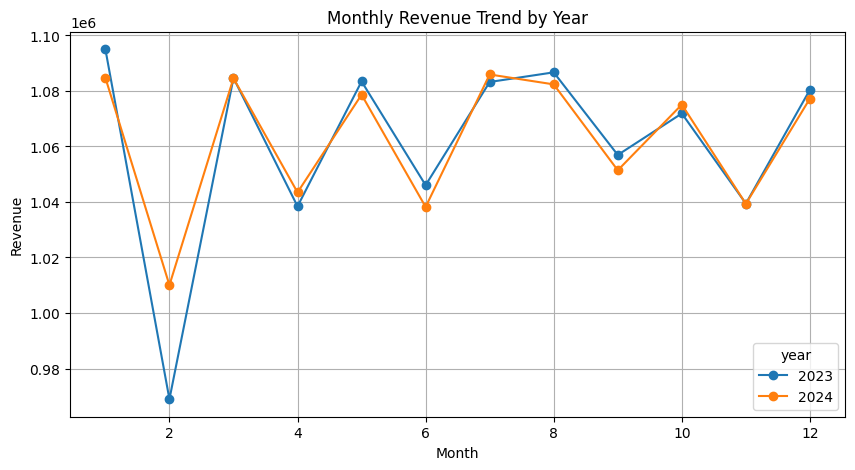

In [23]:
# ============================
# BLOCK 17 — KEY BUSINESS VISUALS
# ============================

import matplotlib.pyplot as plt

# ----------------------------
# 1. Monthly Revenue Trend
# ----------------------------
monthly_trend = df.groupby(['year', 'month'])['revenue'].sum().unstack(0)

monthly_trend.plot(figsize=(10,5), marker='o')
plt.title("Monthly Revenue Trend by Year")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid()
plt.show()

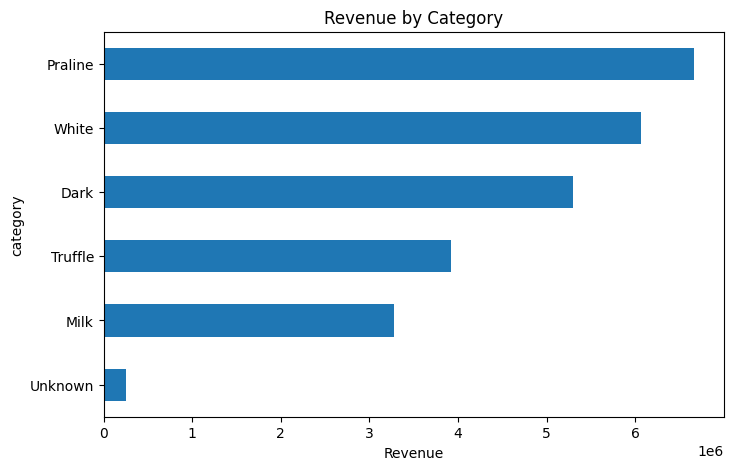

In [24]:

# ----------------------------
# 2. Revenue by Category
# ----------------------------
df.groupby("category")["revenue"].sum().sort_values().plot(
    kind="barh", figsize=(8,5)
)
plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.show()


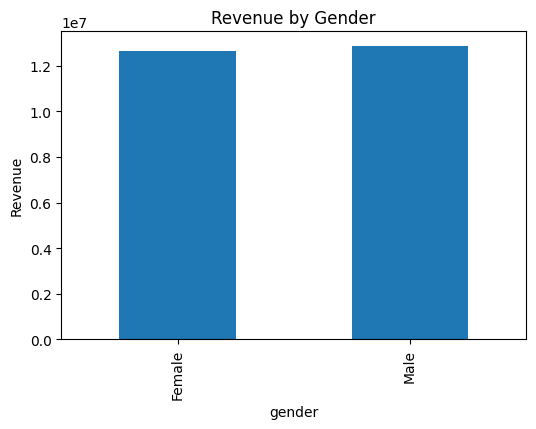

In [25]:
# ----------------------------
# 3. Revenue by Gender
# ----------------------------
df.groupby("gender")["revenue"].sum().plot(
    kind="bar", figsize=(6,4)
)
plt.title("Revenue by Gender")
plt.ylabel("Revenue")
plt.show()


/tmp/ipykernel_20693/3743278830.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["revenue"].sum().plot(


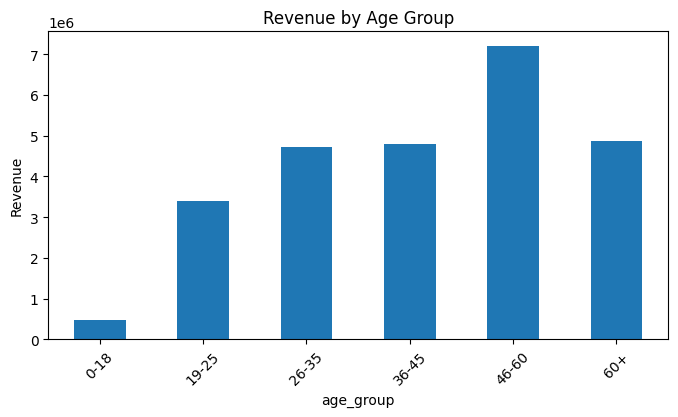

In [26]:
# ----------------------------
# 4. Revenue by Age Group
# ----------------------------
df.groupby("age_group")["revenue"].sum().plot(
    kind="bar", figsize=(8,4)
)
plt.title("Revenue by Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

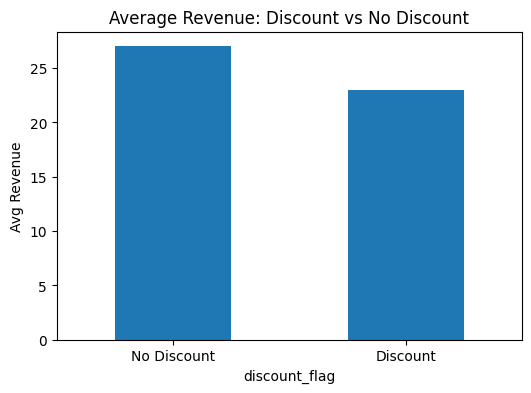

In [27]:
# ----------------------------
# 5. Discount vs No Discount
# ----------------------------
df.groupby("discount_flag")["revenue"].mean().plot(
    kind="bar", figsize=(6,4)
)
plt.title("Average Revenue: Discount vs No Discount")
plt.ylabel("Avg Revenue")
plt.xticks([0,1], ["No Discount", "Discount"], rotation=0)
plt.show()


# ----------------------------
# 6. Weekend vs Weekday
# ----------------------------
df.groupby("is_weekend")["revenue"].mean().plot(
    kind="bar", figsize=(6,4)
)
plt.title("Average Revenue: Weekend vs Weekday")
plt.ylabel("Avg Revenue")
plt.xticks([0,1], ["Weekday", "Weekend"], rotation=0)
plt.show()

# ============================
# VISUAL ANALYSIS — KEY INSIGHTS
# ============================

The visual analysis provides several clear insights into the business performance of the chocolate retail company.

The monthly revenue trend shows that sales remain relatively stable across both 2023 and 2024, with only minor fluctuations. There are no extreme peaks or drops, indicating consistent demand throughout the year. This suggests that chocolate sales are not highly seasonal and that the business benefits from steady revenue streams.

From the category analysis, Praline, White, and Dark chocolates are the top-performing product categories. These categories contribute the majority of revenue, making them critical to the company’s success. On the other hand, the "Unknown" category represents a small portion of revenue, likely due to missing product information, and should be considered a data quality limitation.

Revenue by gender appears balanced, with both male and female customers contributing almost equally. This indicates that the company’s products appeal broadly and are not heavily skewed toward a specific gender.

Looking at age groups, customers between 46–60 generate the highest revenue, followed by the 36–45 and 60+ groups. This suggests that middle-aged and older customers are the primary contributors to sales, and marketing strategies could be tailored to this demographic.

The discount analysis shows an interesting pattern: average revenue per transaction is actually higher when no discount is applied. This indicates that discounts are not the main driver of sales and may even reduce revenue per order. It suggests that customers are willing to purchase products without heavy promotional incentives.

Finally, the comparison between weekday and weekend sales shows very little difference in average revenue. This implies that purchasing behavior is consistent throughout the week, and the business does not rely heavily on weekend spikes.

Overall, these visual insights suggest that sales performance is mainly driven by product categories and customer demographics, rather than timing or discount strategies.

Missing values in model_df:
quantity                0
unit_price              0
discount                0
cost                    0
profit                  0
age                     0
loyalty_member          0
cocoa_percent           0
weight_g                0
year                    0
month                   0
day                     0
quarter                 0
is_weekend              0
avg_selling_price       0
profit_margin           0
discount_flag           0
unknown_product_flag    0
category                0
brand                   0
gender                  0
age_group               0
store_name              0
city                    0
country                 0
revenue                 0
dtype: int64

Correlation with revenue:
revenue                 1.000000
cost                    0.984520
profit                  0.966183
quantity                0.733962
avg_selling_price       0.614519
unit_price              0.599279
day                     0.000975
profit_margin           0

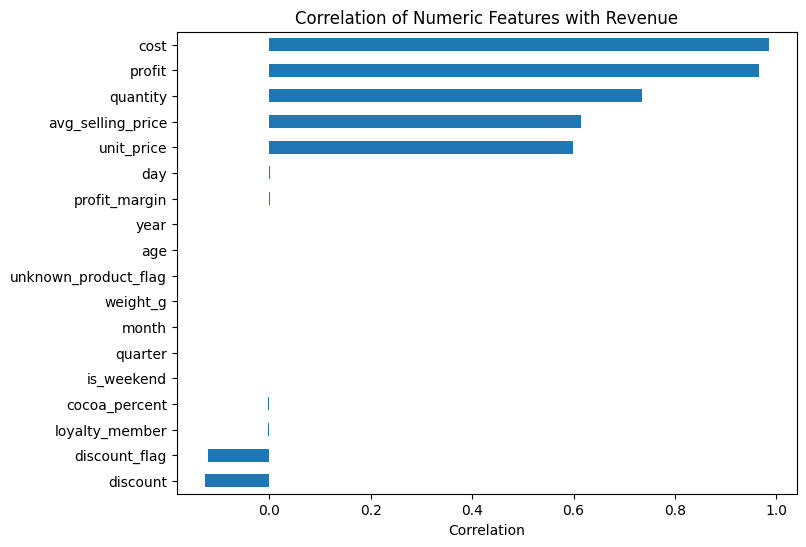


Model dataframe shape: (1000000, 26)


,quantity,unit_price,discount,cost,profit,age,loyalty_member,cocoa_percent,weight_g,year,...,discount_flag,unknown_product_flag,category,brand,gender,age_group,store_name,city,country,revenue
0,5,14.43,0.15,42.77,18.56,44,1,70.0,200.0,2023,...,1,0,White,Hershey,Male,36-45,Chocolate Store 93,Sydney,UK,61.33
1,3,12.01,0.00,19.06,16.97,63,1,60.0,50.0,2023,...,0,0,Praline,Lindt,Female,60+,Chocolate Store 65,New York,Australia,36.03
2,2,10.02,0.00,10.29,9.75,35,1,90.0,50.0,2023,...,0,0,Milk,Hershey,Male,26-35,Chocolate Store 78,London,UK,20.04
3,2,14.66,0.10,16.35,10.04,37,1,60.0,50.0,2024,...,1,0,Praline,Godiva,Female,36-45,Chocolate Store 88,Toronto,USA,26.39
4,1,12.34,0.00,7.94,4.40,57,0,90.0,120.0,2024,...,0,0,Truffle,Hershey,Female,46-60,Chocolate Store 54,London,Canada,12.34


In [30]:
# ============================
# BLOCK 18 — CORRELATION + ML DATASET PREPARATION
# ============================

# We will predict revenue
target = "revenue"

# ----------------------------
# 1. Select useful columns
# ----------------------------
model_df = df.copy()

selected_columns = [
    "quantity",
    "unit_price",
    "discount",
    "cost",
    "profit",
    "age",
    "loyalty_member",
    "cocoa_percent",
    "weight_g",
    "year",
    "month",
    "day",
    "quarter",
    "is_weekend",
    "avg_selling_price",
    "profit_margin",
    "discount_flag",
    "unknown_product_flag",
    "category",
    "brand",
    "gender",
    "age_group",
    "store_name",
    "city",
    "country",
    "target_audience",
    target
]

# Keep only columns that actually exist
selected_columns = [col for col in selected_columns if col in model_df.columns]
model_df = model_df[selected_columns]

# ----------------------------
# 2. Full missing-value check
# ----------------------------
print("Missing values in model_df:")
print(model_df.isnull().sum().sort_values(ascending=False))

# ----------------------------
# 3. Correlation on numeric columns
# ----------------------------
numeric_df = model_df.select_dtypes(include=["number"])

corr_with_target = numeric_df.corr()[target].sort_values(ascending=False)

print("\nCorrelation with revenue:")
print(corr_with_target)

# ----------------------------
# 4. Plot top correlations
# ----------------------------
import matplotlib.pyplot as plt

corr_with_target.drop(target).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Correlation of Numeric Features with Revenue")
plt.xlabel("Correlation")
plt.show()

# ----------------------------
# 5. Preview modeling dataframe
# ----------------------------
print("\nModel dataframe shape:", model_df.shape)
display(model_df.head())

### Correlation Analysis (Including Derived Features)

In this step, a correlation analysis was performed to examine the relationship between numerical features and the target variable (revenue).

The results show very strong positive correlations for:
- `cost` (0.98) (data leak)
- `profit` (0.97) (data leak)
- `quantity` (0.73)
- `avg_selling_price` (0.61) (data leak)
- `unit_price` (0.60)

These results indicate that sales volume and pricing are key drivers of revenue. Discount variables show a negative correlation, suggesting that higher discounts tend to reduce overall revenue.

It is important to note that some features such as `cost`, `profit`, `avg_selling_price`, and `profit_margin` are directly derived from or closely related to revenue. Therefore, their high correlation is expected and does not necessarily indicate true predictive power.

These features are included here for exploratory analysis only and will be removed in the next step to prevent data leakage and ensure a fair and realistic machine learning model.

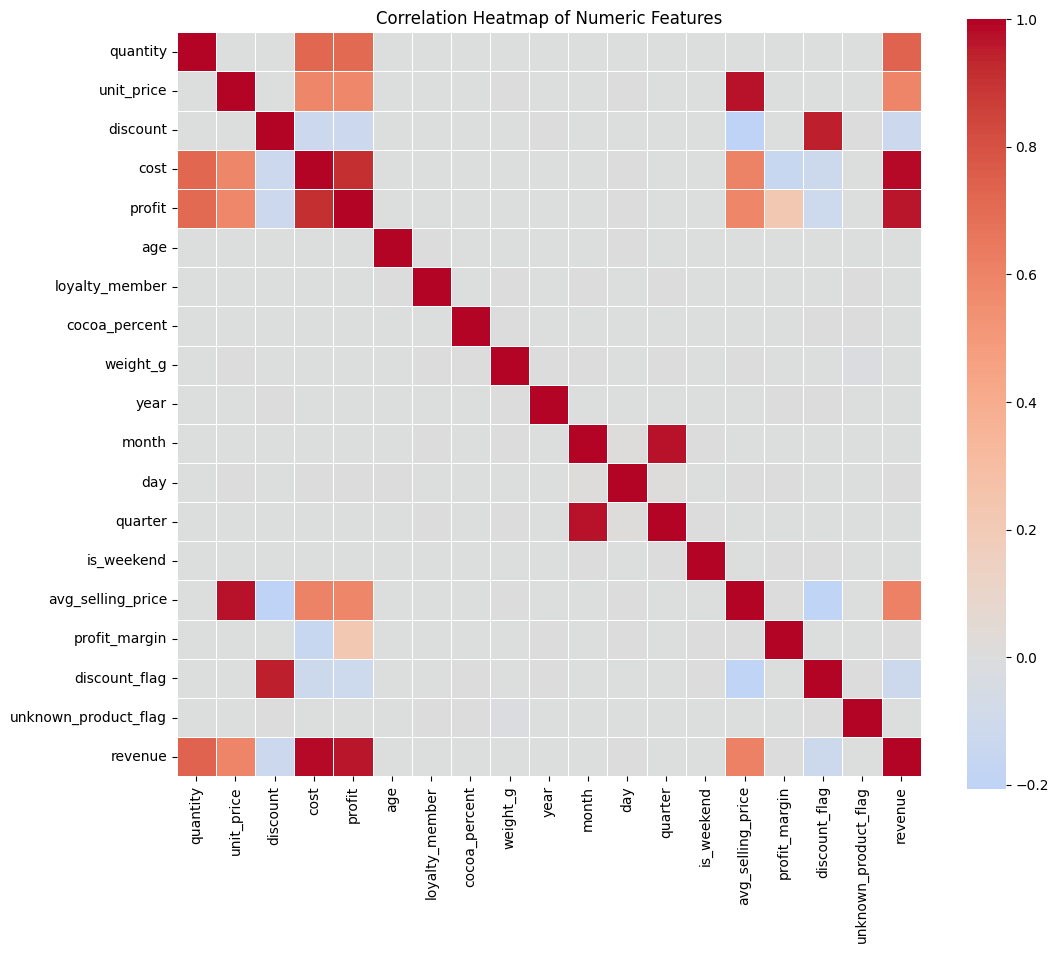

In [31]:
# ============================
# BLOCK 18.5 — CORRELATION HEATMAP
# ============================

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = model_df.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

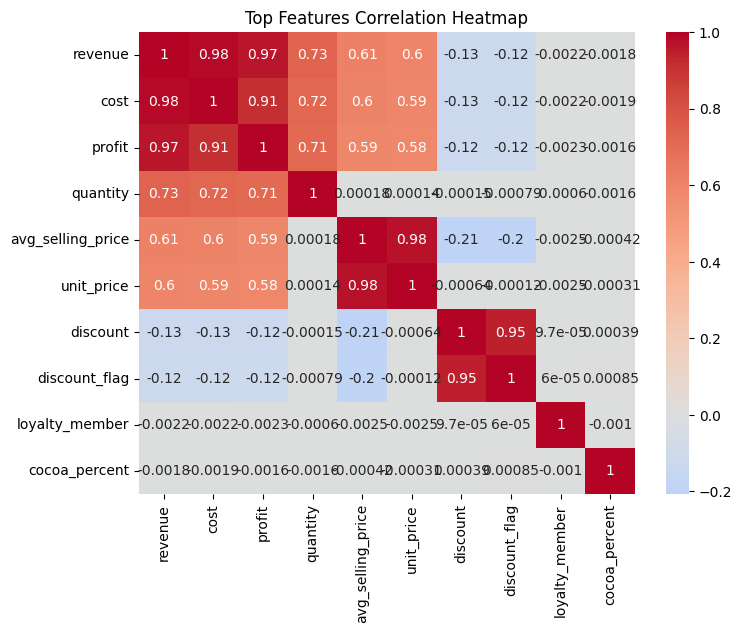

In [32]:
# ============================
# BLOCK 18.6 — FOCUSED HEATMAP (TOP FEATURES)
# ============================

# Select top correlated features with revenue
top_features = corr_with_target.abs().sort_values(ascending=False).head(10).index

# Create smaller correlation matrix
focused_corr = numeric_df[top_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    focused_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Top Features Correlation Heatmap")
plt.show()

### Correlation Heatmap Analysis

To better understand the relationships between variables, two correlation heatmaps were generated: a full heatmap including all numerical features, and a focused heatmap highlighting the top features most strongly correlated with revenue.

The full heatmap provides an overall view of relationships within the dataset. It shows strong positive correlations between `revenue`, `cost`, and `profit`, as well as between `quantity` and `revenue`, and between `unit_price` and `avg_selling_price`. These relationships are expected, as revenue is directly influenced by sales volume and pricing.

The focused heatmap highlights the top features most relevant to revenue, making the relationships easier to interpret. It confirms that `quantity`, `unit_price`, and `avg_selling_price` are among the strongest drivers of revenue, while discount-related features (`discount`, `discount_flag`) show negative correlations, indicating that higher discounts tend to reduce total revenue.

It is important to note that some features, such as `cost`, `profit`, `avg_selling_price`, and `profit_margin`, are derived from or closely related to revenue. Their strong correlations are therefore expected and are included here only for exploratory analysis. These features will be removed in the modeling stage to prevent data leakage.

Overall, the heatmaps provide both a comprehensive and focused understanding of feature relationships, helping guide feature selection and supporting the development of a reliable predictive model.

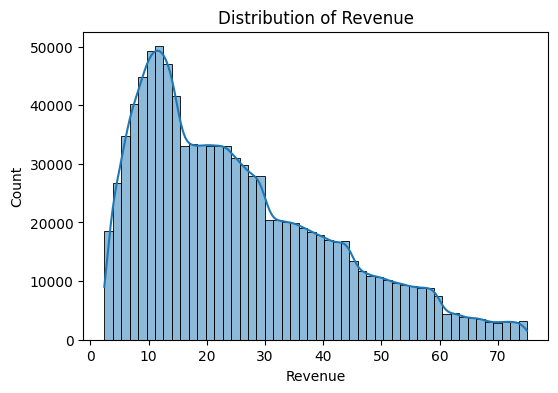

In [33]:
# ============================
# BLOCK 18.7 — DISTRIBUTIONS + RELATIONSHIPS
# ============================

import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# 1. Revenue distribution
# ----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df["revenue"], bins=50, kde=True)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.show()

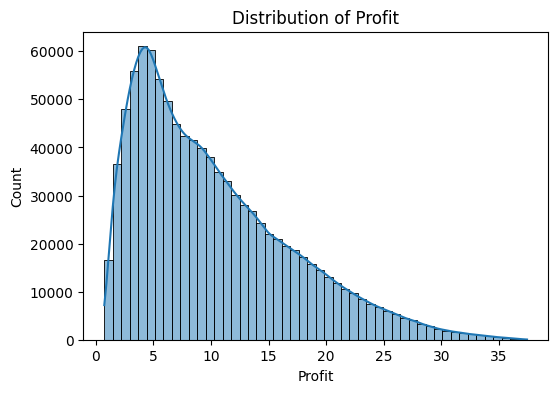

In [34]:
# ----------------------------
# 2. Profit distribution
# ----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df["profit"], bins=50, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.show()


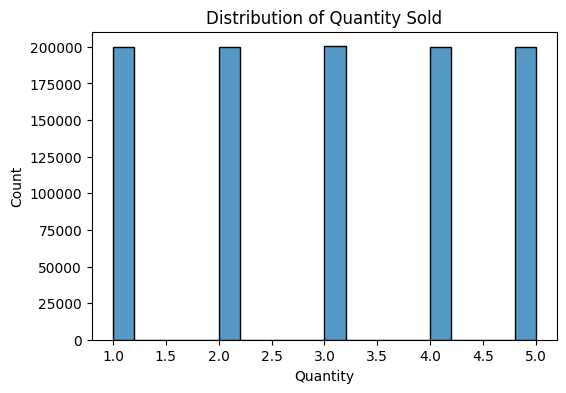

In [35]:
# ----------------------------
# 3. Quantity distribution
# ----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df["quantity"], bins=20, kde=False)
plt.title("Distribution of Quantity Sold")
plt.xlabel("Quantity")
plt.show()

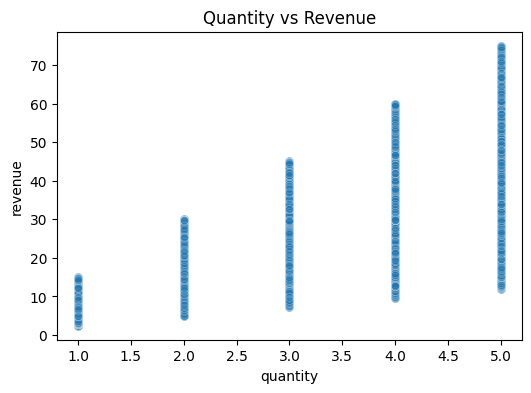

In [36]:
# ----------------------------
# 4. Quantity vs Revenue
# ----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["quantity"], y=df["revenue"], alpha=0.3)
plt.title("Quantity vs Revenue")
plt.show()

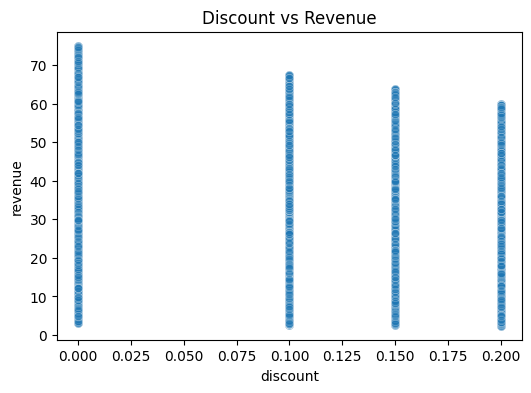

In [37]:
# ----------------------------
# 5. Discount vs Revenue
# ----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["discount"], y=df["revenue"], alpha=0.3)
plt.title("Discount vs Revenue")
plt.show()

### Distribution and Relationship Analysis

The distribution plots provide key insights into the behavior of important variables across transactions.

The revenue distribution is right-skewed, indicating that most transactions generate low to moderate revenue, while a smaller number of transactions contribute higher revenue values. This pattern is common in retail environments, where a limited number of larger purchases account for a significant portion of total sales.

Similarly, the profit distribution is also right-skewed, suggesting that most transactions yield moderate profit levels, with fewer high-profit cases. This indicates relatively consistent profitability across transactions rather than dependence on a small number of extreme values.

The quantity distribution shows that customers typically purchase between 1 and 5 units per transaction, with no significant outliers. This reflects stable and predictable purchasing behavior.

From the relationship plots, a clear positive relationship is observed between quantity and revenue. As the number of units purchased increases, revenue increases proportionally, confirming that quantity is a key driver of sales performance.

In contrast, the relationship between discount and revenue appears slightly negative. Higher discount levels are generally associated with lower revenue values, suggesting that discounts reduce revenue per transaction rather than significantly boosting sales volume.

Overall, the analysis indicates that revenue is primarily driven by sales quantity and pricing, while discounting has a limited or potentially negative impact on overall revenue performance.

These insights are useful for optimizing pricing strategies and minimizing unnecessary discounting.

In [39]:
# ============================
# BLOCK 19 — FINAL MODEL DATASET (NO LEAKAGE)
# ============================

# Target variable
target = "revenue"

# Copy dataset
model_df = df.copy()

# ----------------------------
# Remove leakage / problematic / ID-like features
# ----------------------------
remove_cols = [
    "revenue",            # target
    "profit",             # derived from revenue
    "avg_selling_price",  # derived from revenue
    "profit_margin",      # derived
    "cost",               # highly related to revenue
    "order_id",           # unique identifier
    "customer_id",        # identifier
    "product_id",         # identifier
    "store_id",           # identifier
    "date"                # duplicate of order_date/calendar join field
]

# Keep only safe features
features = [col for col in model_df.columns if col not in remove_cols]

# Final dataset
model_df = model_df[features + [target]].copy()

# ----------------------------
# Quick check
# ----------------------------
print("Final shape:", model_df.shape)
print("\nColumns used for modeling:\n")
print(model_df.columns.tolist())

print("\nMissing values:\n")
print(model_df.isnull().sum().sort_values(ascending=False).head(10))

display(model_df.head())

Final shape: (1000000, 32)

Columns used for modeling:

['order_date', 'quantity', 'unit_price', 'discount', 'age', 'gender', 'loyalty_member', 'join_date', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'city', 'country', 'store_type', 'year', 'month', 'day', 'week', 'day_of_week', 'quarter', 'day_name', 'is_weekend', 'age_group', 'discount_flag', 'discount_band', 'unknown_product_flag', 'unknown_store_flag', 'unknown_customer_city_flag', 'revenue']

Missing values:

order_date        0
quantity          0
unit_price        0
discount          0
age               0
gender            0
loyalty_member    0
join_date         0
product_name      0
brand             0
dtype: int64


,order_date,quantity,unit_price,discount,age,gender,loyalty_member,join_date,product_name,brand,...,quarter,day_name,is_weekend,age_group,discount_flag,discount_band,unknown_product_flag,unknown_store_flag,unknown_customer_city_flag,revenue
0,2023-01-07,5,14.43,0.15,44,Male,1,2021-11-17,Praline Chocolate 70%,Hershey,...,1,Saturday,1,36-45,1,Low,0,0,0,61.33
1,2023-10-22,3,12.01,0.00,63,Female,1,2023-07-03,Dark Chocolate 60%,Lindt,...,4,Sunday,1,60+,0,No Discount,0,0,0,36.03
2,2023-05-07,2,10.02,0.00,35,Male,1,2023-10-09,Milk Chocolate 90%,Hershey,...,2,Sunday,1,26-35,0,No Discount,0,0,0,20.04
3,2024-06-23,2,14.66,0.10,37,Female,1,2023-05-30,Dark Chocolate 60%,Godiva,...,2,Sunday,1,36-45,1,Low,0,0,0,26.39
4,2024-09-24,1,12.34,0.00,57,Female,0,2021-08-20,Truffle Chocolate 90%,Hershey,...,3,Tuesday,0,46-60,0,No Discount,0,0,0,12.34


### Final Model Dataset Preparation

In this step, the final dataset for machine learning was prepared by removing features that could cause data leakage or provide unrealistic predictive power.

Variables such as `profit`, `avg_selling_price`, `profit_margin`, and `cost` were excluded because they are directly derived from or highly dependent on revenue. In addition, identifier columns that do not carry meaningful predictive information were removed to improve model quality and reduce noise.

The resulting dataset contains only safe and relevant features, making it suitable for fair and reliable revenue prediction.

In [40]:
# ============================
# BLOCK 20 — CLEAN FEATURE SET + TRAIN/TEST SPLIT
# ============================

from sklearn.model_selection import train_test_split

# Target
target = "revenue"

# Columns to remove before modeling
drop_cols = [
    "order_date",     # raw date
    "join_date",      # raw date
    "product_name",   # high-cardinality text-like label
    "store_name",     # store label, city/store_type already capture location info
    "day_name"        # duplicates day_of_week
]

# Clean modeling dataframe
model_df = model_df.drop(columns=drop_cols, errors="ignore").copy()

# Split X and y
X = model_df.drop(columns=[target])
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:\n")
print(X.columns.tolist())

# Separate numeric and categorical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

X shape: (1000000, 26)
y shape: (1000000,)

Feature columns:

['quantity', 'unit_price', 'discount', 'age', 'gender', 'loyalty_member', 'brand', 'category', 'cocoa_percent', 'weight_g', 'city', 'country', 'store_type', 'year', 'month', 'day', 'week', 'day_of_week', 'quarter', 'is_weekend', 'age_group', 'discount_flag', 'discount_band', 'unknown_product_flag', 'unknown_store_flag', 'unknown_customer_city_flag']

Categorical columns:
['gender', 'brand', 'category', 'city', 'country', 'store_type', 'age_group', 'discount_band']

Numeric columns:
['quantity', 'unit_price', 'discount', 'age', 'loyalty_member', 'cocoa_percent', 'weight_g', 'year', 'month', 'day', 'week', 'day_of_week', 'quarter', 'is_weekend', 'discount_flag', 'unknown_product_flag', 'unknown_store_flag', 'unknown_customer_city_flag']

Train shape: (800000, 26) (800000,)
Test shape: (200000, 26) (200000,)


### Cleaning the Feature Set and Train-Test Split

In this step, the feature set was refined before model training by removing raw date columns and high-cardinality text-based variables that are not suitable for direct modeling.

The dataset was then separated into input features (`X`) and the target variable (`y`), where revenue is the prediction target. The features were further categorized into numerical and categorical variables to support appropriate preprocessing in the machine learning pipeline.

The final feature set consists of 26 variables with no missing values, ensuring data quality and consistency.

The dataset was then split into training and testing sets using an 80:20 ratio:
- Training set: 800,000 observations  
- Testing set: 200,000 observations  

This allows the model to be trained on one portion of the data and evaluated on unseen data, ensuring a fair and reliable assessment of model performance.

In [41]:
# ============================
# BLOCK 21 — PREPROCESSING + BASELINE MODEL (MANUAL VERSION)
# ============================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ----------------------------
# Preprocessing setup
# ----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# ----------------------------
# Fit and transform training data
# ----------------------------
print("Preprocessing training data...")
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
print("Preprocessing test data...")
X_test_processed = preprocessor.transform(X_test)

# ----------------------------
# Model
# ----------------------------
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# ----------------------------
# Train model
# ----------------------------
print("Training model...")
model.fit(X_train_processed, y_train)

# ----------------------------
# Predictions
# ----------------------------
y_pred = model.predict(X_test_processed)

# ----------------------------
# Evaluation
# ----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# ----------------------------
#  show transformed shape
# ----------------------------
print("\nProcessed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Preprocessing training data...
Preprocessing test data...
Training model...

Model Performance:
RMSE: 2.6596
R2 Score: 0.9736

Processed training shape: (800000, 58)
Processed test shape: (200000, 58)


### Preprocessing and Baseline Model Development

In this step, the dataset was prepared for machine learning and a baseline model was developed.

A preprocessing pipeline was created using a ColumnTransformer, where numerical features were scaled using StandardScaler and categorical features were encoded using One-Hot Encoding. This ensures that all features are in an appropriate format for model training.

The preprocessing pipeline was fitted on the training data and then applied to both the training and test sets, ensuring that no information from the test data was used during training.

A Random Forest Regressor was selected as the baseline model due to its ability to handle complex, non-linear relationships and its robustness with mixed data types. The model was trained using the processed training dataset.

Model performance was evaluated on the test dataset using:
- **RMSE: 2.6596**, indicating a low prediction error
- **R² Score: 0.9736**, meaning the model explains approximately 97.36% of the variance in revenue

These results indicate that the model performs very well and is able to accurately predict revenue based on the selected features.

After preprocessing, the dataset expanded to 58 features due to one-hot encoding of categorical variables, resulting in:
- Training set: 800,000 rows × 58 features  
- Testing set: 200,000 rows × 58 features  

This baseline model provides a strong foundation for further analysis, comparison, and model improvement.

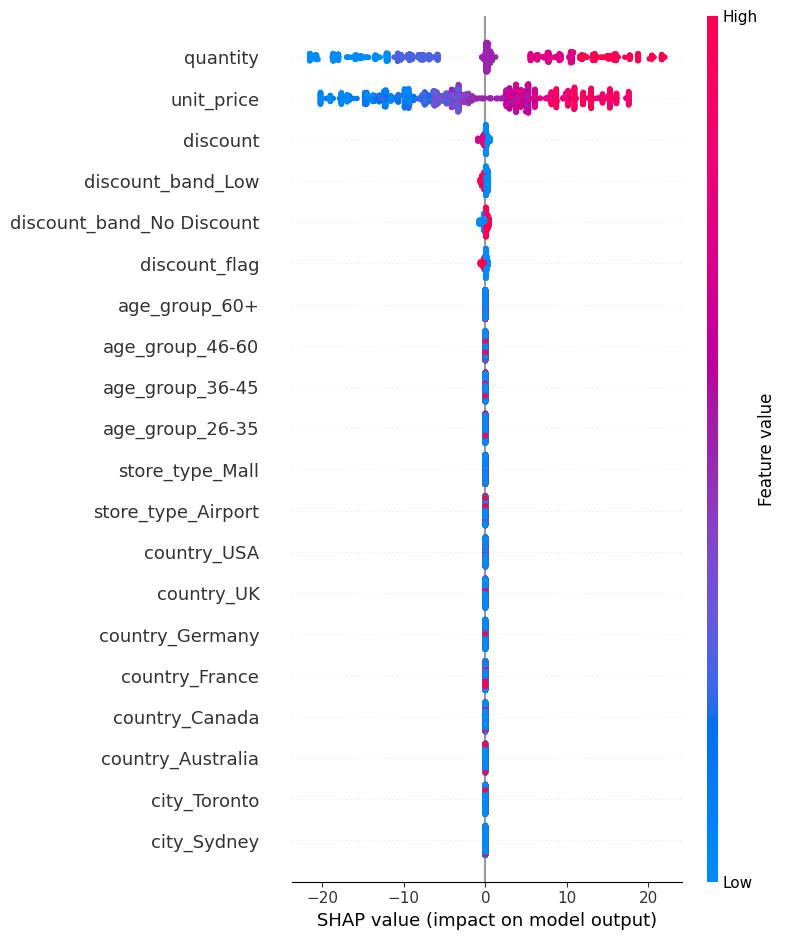

Top 10 most important features:


,Feature,Mean |SHAP|
0,quantity,10.151639
1,unit_price,8.518572
2,discount,0.194387
56,discount_band_Low,0.189201
57,discount_band_No Discount,0.162827
14,discount_flag,0.154310
6,weight_g,0.000000
7,year,0.000000
4,loyalty_member,0.000000
3,age,0.000000


In [42]:
# ============================
# BLOCK 22 — SHAP EXPLAINABILITY
# ============================

import shap
import pandas as pd
import numpy as np

# ----------------------------
# Get final feature names after preprocessing
# ----------------------------
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(cat_feature_names)

# ----------------------------
# Convert processed training data to dense if needed
# ----------------------------
if hasattr(X_train_processed, "toarray"):
    X_train_dense = X_train_processed.toarray()
else:
    X_train_dense = X_train_processed

# ----------------------------
# Small sample for SHAP (for speed)
# ----------------------------
sample_size = 2000
X_shap_sample = X_train_dense[:sample_size]

# ----------------------------
# SHAP explainer
# ----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

# ----------------------------
# SHAP summary plot
# ----------------------------
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=all_feature_names
)

# ----------------------------
# Mean absolute SHAP importance table
# ----------------------------
mean_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Mean |SHAP|": mean_shap
}).sort_values(by="Mean |SHAP|", ascending=False)

print("Top 10 most important features:")
display(shap_importance.head(10))

### Model Explainability using SHAP

To understand how the model makes predictions, SHAP (SHapley Additive exPlanations) was used as an explainability technique. SHAP helps quantify the contribution of each feature to the model’s predictions.

A SHAP summary plot was generated to visualize the impact of features on revenue prediction. The results show that:

- **Quantity** is the most important feature, with the highest SHAP value (~10.15), indicating that higher quantities strongly increase revenue.
- **Unit price** is the second most important feature (~8.52), confirming that pricing plays a major role in determining revenue.
- **Discount** and discount-related features (such as `discount_flag` and `discount_band`) have a smaller but noticeable impact, generally reducing revenue as discount levels increase.
- Other features such as age, loyalty membership, and product attributes have minimal direct impact on revenue, as indicated by near-zero SHAP values.

The SHAP plot also shows the direction of influence:
- Higher values of quantity and unit price (red points) push predictions toward higher revenue.
- Higher discount values tend to push predictions toward lower revenue.

These results align with business expectations, where revenue is primarily driven by sales volume and pricing, while discounts reduce overall revenue per transaction.

Overall, SHAP provides a transparent and interpretable explanation of the model, confirming that it is learning meaningful and realistic relationships from the data.

In [43]:
# ============================
# BLOCK 23 — BIAS ANALYSIS
# ============================

import pandas as pd
from sklearn.metrics import mean_squared_error

# ----------------------------
# Create evaluation dataframe
# ----------------------------
results_df = X_test.copy()
results_df["actual"] = y_test
results_df["predicted"] = y_pred

# ----------------------------
# Function to compute RMSE by group
# ----------------------------
def group_rmse(df, group_col):
    grouped = df.groupby(group_col)

    rmse_list = []

    for name, group in grouped:
        rmse = mean_squared_error(group["actual"], group["predicted"]) ** 0.5
        rmse_list.append((name, rmse))

    return pd.DataFrame(rmse_list, columns=[group_col, "RMSE"]).sort_values(by="RMSE")

# ----------------------------
# Gender bias
# ----------------------------
print("\nGender RMSE:")
display(group_rmse(results_df, "gender"))

# ----------------------------
# Age group bias
# ----------------------------
print("\nAge Group RMSE:")
display(group_rmse(results_df, "age_group"))

# ----------------------------
# Store type bias
# ----------------------------
print("\nStore Type RMSE:")
display(group_rmse(results_df, "store_type"))


Gender RMSE:


,gender,RMSE
0,Female,2.651261
1,Male,2.667748



Age Group RMSE:


/tmp/ipykernel_20693/1257213815.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_col)


,age_group,RMSE
0,0-18,2.626700
4,46-60,2.654591
3,36-45,2.657223
1,19-25,2.657990
2,26-35,2.663762
5,60+,2.669523



Store Type RMSE:


,store_type,RMSE
0,Airport,2.643681
1,Mall,2.659699
3,Retail,2.660013
2,Online,2.678062


### Bias Analysis

To evaluate the fairness of the model, a bias analysis was conducted by comparing prediction errors (RMSE) across different groups, including gender, age group, and store type.

#### Gender
The RMSE values are:
- Female: 2.6513  
- Male: 2.6677  

The difference in error between genders is very small, indicating that the model performs consistently for both groups without significant bias.

#### Age Group
The RMSE values across age groups range from approximately 2.63 to 2.67:
- Lowest error: 0–18 (2.6267)  
- Highest error: 60+ (2.6695)  

The variation is minimal, suggesting that the model maintains similar performance across all age groups.

#### Store Type
The RMSE values are:
- Airport: 2.6437  
- Mall: 2.6597  
- Retail: 2.6600  
- Online: 2.6781  

Again, the differences are very small, indicating consistent model performance across different store types.

#### Conclusion
Overall, the model demonstrates stable and consistent performance across all evaluated groups. The small differences in RMSE suggest that there is no significant bias in predictions based on gender, age, or store type.

This indicates that the model is fair and generalizes well across different segments of the data.

In [44]:
# ============================
# BLOCK 24 — DEPLOYMENT PREPARATION (SAVE MODEL + SCORING FUNCTION)
# ============================

import joblib
import pandas as pd

# ----------------------------
# Save the trained preprocessor and model
# ----------------------------
joblib.dump(preprocessor, "chocolate_sales_preprocessor.pkl")
joblib.dump(model, "chocolate_sales_model.pkl")

print("Saved files:")
print("- chocolate_sales_preprocessor.pkl")
print("- chocolate_sales_model.pkl")

# ----------------------------
# Scoring function
# ----------------------------
def predict_revenue(input_df):
    """
    input_df: pandas DataFrame with the same input columns as X_train
    returns: predicted revenue
    """
    processed_data = preprocessor.transform(input_df)
    predictions = model.predict(processed_data)
    return predictions

# ----------------------------
# Test scoring function on 5 rows
# ----------------------------
sample_input = X_test.head(5).copy()
sample_predictions = predict_revenue(sample_input)

results = sample_input.copy()
results["Predicted_Revenue"] = sample_predictions

print("\nSample scoring output:")
display(results)

Saved files:
- chocolate_sales_preprocessor.pkl
- chocolate_sales_model.pkl

Sample scoring output:


,quantity,unit_price,discount,age,gender,loyalty_member,brand,category,cocoa_percent,weight_g,...,day_of_week,quarter,is_weekend,age_group,discount_flag,discount_band,unknown_product_flag,unknown_store_flag,unknown_customer_city_flag,Predicted_Revenue
987231,2,13.15,0.0,30,Female,1,Mars,White,80.0,120.0,...,5,1,1,26-35,0,No Discount,0,0,0,26.469016
79954,4,4.90,0.2,43,Female,1,Mars,White,90.0,80.0,...,1,1,0,36-45,1,Low,0,0,0,19.083574
567130,1,14.47,0.0,27,Male,1,Mars,White,50.0,50.0,...,0,1,0,26-35,0,No Discount,0,0,0,13.296327
500891,3,5.63,0.1,40,Male,1,Lindt,Dark,80.0,80.0,...,2,3,0,36-45,1,Low,0,0,0,15.702759
55399,1,11.77,0.0,46,Male,0,Godiva,Praline,80.0,200.0,...,0,1,0,46-60,0,No Discount,0,0,0,10.336966


### Deployment Preparation and Model Scoring

In this step, the trained preprocessing pipeline and machine learning model were saved as `.pkl` files using `joblib`. The saved files are:

- `chocolate_sales_preprocessor.pkl`
- `chocolate_sales_model.pkl`

This makes the solution reusable and demonstrates deployment readiness, since the model can be loaded later without retraining.

A scoring function named `predict_revenue()` was also created to simulate how the model would be used in a real-world deployment scenario. The function accepts new input data, applies the saved preprocessing steps, and returns predicted revenue values.

To validate the deployment setup, the scoring function was tested on five sample rows from the test set. The model successfully generated predicted revenue values for all records, confirming that the end-to-end prediction pipeline works correctly.

This step satisfies the deployment preparation requirement by demonstrating both model persistence and practical scoring on unseen data.